# Lesson 117 · RDL bridge: from database rows to predictions

Student lab · Three live TODO/CHECK tasks. The default run applies your functions to genuine F1 rows. The full five-seed benchmark is a separate optional gate.

In [ ]:
# Install missing packages only. Full benchmark runtime is pinned separately.
import importlib.util,importlib.metadata,subprocess,sys
required={'numpy':'numpy','pandas':'pandas','pyarrow':'pyarrow','torch':'torch','torch_frame':'pytorch-frame==0.2.3','torch_geometric':'torch-geometric==2.6.1','relbench':'relbench==1.1.0','pooch':'pooch'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Actual notebook runtime:',sys.version)
print({k:importlib.metadata.version(k) for k in ['numpy','pandas','torch','pytorch-frame','torch-geometric','relbench']})


## Execution contract

The default lab downloads less than 1 MB of hash-checked data and uses NumPy/pandas for the learner tasks. Full model definitions are visible and executed as definitions; they do not train until you enable the final gate. The author GPU environment is Python 3.11, torch 2.5.1+cu124, PyG 2.6.1, Frame 0.2.3, RelBench 1.1.0 and pyg-lib 0.4.0. Existing notebook packages are reported, not silently claimed identical. Install sentence-transformers and compatible native pyg-lib before opting into the full gate; use the pinned environment and bounded Modal runner in the protocol for exact author commands. Live Colab NOT_CHECKED. No cloud job is launched automatically.

<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 116 to this lesson</p>
<p>You can now design and debug a GNN. Relational learning adds the missing input question: how do database rows become a query-specific graph?</p>
<details><summary>Quick prerequisite reminder</summary><p>A schema describes tables and key roles. A relational entity graph contains actual rows and key links. A computation graph contains the sampled occurrences used for one prediction.</p></details>
</aside>
<!-- sequence-review:end -->

<p class="stream-kicker">From graph machinery to a database prediction</p>

**Your win:** start with a relational schema and a prediction request, construct the right graph, and explain exactly which rows can influence the prediction. Then follow a complete RDL training run on real Formula One data.

[Student notebook](https://avistian.github.io/relational/labs/0117-rdl-bridge.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0117-rdl-bridge.html) · [Quick reference](https://avistian.github.io/relational/reference/rdl-bridge.html) · [Reproduction protocol](https://avistian.github.io/relational/labs/l117-reproduction.md)

Take Sections 1–4 as the first study session. Continue with the model trace and notebook in a second session. The full benchmark is an author-reference experiment; running its cells is not a substitute for defending your own construction.

Without notes: what does a row encoder produce? What is the difference between a global node ID and a sampled local position? Which timestamp bounds a two-hop temporal neighborhood?



## 1 · The bridge: a prediction request determines a computation

[Lesson 115](https://avistian.github.io/relational/lessons/0115-graph-ml-design-patterns.html) split a graph predictor into encoder, message passing, and head. [Lesson 116](https://avistian.github.io/relational/lessons/0116-debug-gnn-training.html) checked that the training loop actually updates the intended model. Both started with an existing graph. A business database supplies tables, keys, timestamps, and a question. This lesson fills that missing first step.

Suppose you want to predict a driver's average finishing position over the next 60 days. The driver's own table can describe nationality and date of birth. Their previous races live elsewhere. Race results connect the driver to races and constructors; races connect to circuits. The information is distributed, but the primary–foreign key relationships already identify which rows belong together.

**Relational deep learning (RDL)** learns from that connected data by representing rows as graph nodes, key references as edges, and column values as node inputs. The model learns how to combine context for the chosen prediction task. This is the blueprint in [Fey et al., §§2–3 and Figures 2–4](https://proceedings.mlr.press/v235/fey24a.html).

It does not remove the need to define the target, decide when information becomes available, interpret table semantics, or evaluate fairly. A competent feature engineer can also use related tables. The empirical question is whether the learned pipeline improves the chosen accuracy, effort, or maintenance tradeoff under matched information access. Keep this distinction when assessing the course mission.

**Retrieve before continuing.** What does a foreign key tell you that a numeric feature does not? Why does knowing a result today fail to authorize it for a prediction made last year?

<details><summary>Check the distinction</summary><p>A foreign key identifies another entity; its numeric magnitude normally has no useful distance interpretation. A row can be present in today's archive while remaining unavailable at a historical query time. Representation and availability are separate contracts.</p></details>



## 2 · Three graphs, three different questions

A **primary key** uniquely identifies a row within its table. A **foreign key** references a primary key in another table. A **node type** records which table supplied a row; an **edge type** records the relationship used to connect two rows. Two columns pointing to the same table can represent different relationships, so preserve their column names in relation types.

| Object | A node represents | What it tells us |
|---|---|---|
| Schema graph | One table | Which kinds of entities can be related |
| Relational entity graph (REG) | One row | Which particular entities are related |
| Query computation graph | A sampled copy of a row for one query | Which permitted messages are computed for this prediction |

<figure class="stream-figure" tabindex="0">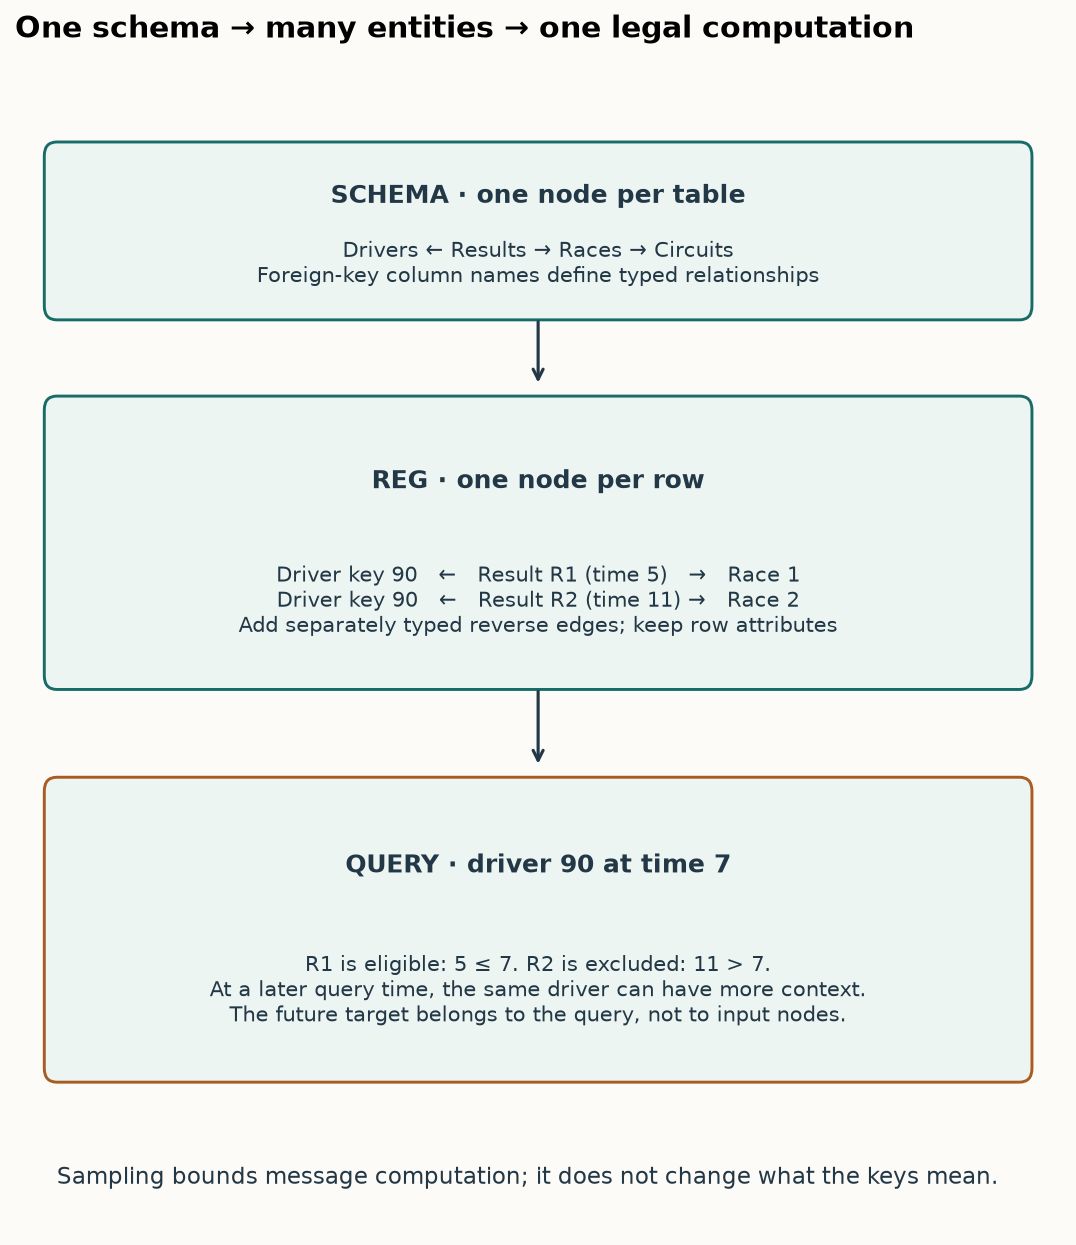<figcaption>Schema nodes denote tables; REG nodes denote individual rows; a query extracts eligible context using one fixed prediction time.</figcaption></figure>

For the schema `drivers ← results → races → circuits`, the REG has one node for every individual driver, result, race, and circuit row. A result is itself a node, not merely an edge: it has useful attributes such as finishing position. This preserves the grain of a fact table—the event represented by each row. [Fey §2.1, §3.1–3.2](https://proceedings.mlr.press/v235/fey24a.html).

**Worked key mapping.** The drivers table is stored in order `[90, 10, 40]`. Four result rows contain driver keys `[40, null, 90, 40]`. Their graph connections, expressed as `(result row position, driver row position)`, are `(0,2), (2,0), (3,2)`. Key 40 maps to row position 2, not position 40. The null creates no relationship. Duplicate primary keys or unknown non-null foreign keys require an explicit policy; our teaching constructor rejects them rather than guessing.

The released RelBench data has already remapped primary keys to contiguous row indices. Its loader censors rows after the test cutoff and marks references to removed rows as null. Our audit verifies the actual resulting graph; the notebook also practices arbitrary-key mapping so the release convention does not become an accidental general assumption. [Pinned graph constructor](https://avistian.github.io/relational/labs/sources/l117/graph.py).

### Why add reverse edges?

The stored foreign key points from a result to its driver. To let a driver collect messages from results, the computation also needs the reverse relationship. The release creates separately typed directions, for example `results → drivers` and `drivers → results`. The neural transformations can differ by direction. This does not make the database constraint bidirectional or invent a causal relationship.

**Task 1 — construct the relationships.** Implement `foreign_key_edges(primary_keys, foreign_keys)`. CHECK tests noncontiguous keys, repeated references, nulls, duplicate keys, and unknown references. The complete real-data audit applies the same mapping to every foreign-key column and compares all graph edges.



## 3 · The training table describes questions, not new entity features

A **query** is an entity ID paired with a prediction time. A **target window** is the future interval from which the answer is computed. A **training table** contains the query's entity ID, timestamp, and target. It supplies supervised examples; the target column is not an input feature attached to every entity node.

For `rel-f1/driver-position`, each query asks for a driver's mean finishing position over the next 60 days. If two eligible future race finishes are 3 and 7, the target is `(3+7)/2 = 5`. Those results help define the label but cannot be read as predictor inputs at the earlier query time. The same driver's earlier results may be legitimate input. [Task definition and Table 2](https://arxiv.org/html/2407.20060v1#S5).

A single driver can appear at multiple query times with different labels and different neighborhoods. A static label array indexed by driver ID cannot represent that task. During sampling, RelBench carries `input_id`, the original **query-row index**. `n_id` instead maps a sampled node to its global **entity-row index**. These two index spaces are not interchangeable. [Released target transform](https://avistian.github.io/relational/labs/sources/l117/graph.py).

<figure class="stream-figure" tabindex="0">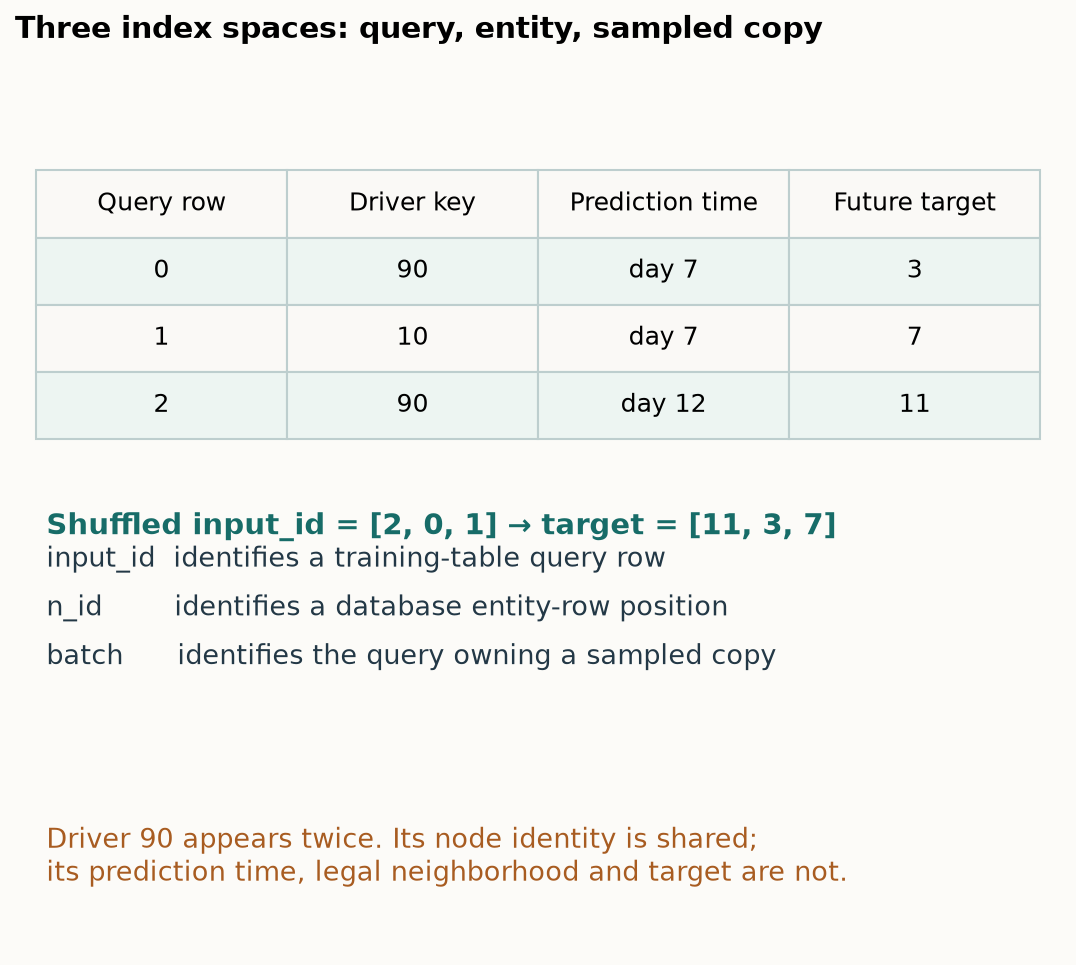<figcaption>input_id selects a query and its target; n_id identifies a database row; batch identifies which query owns the sampled copy.</figcaption></figure>

**Worked trace.** Query rows 0 and 2 both refer to driver 90, but their targets are 3 and 11. Query row 1 refers to another driver and has target 7. A shuffled batch with `input_id=[2,0,1]` must receive `[11,3,7]`. Looking up a label by driver ID would collapse the two predictions for driver 90.

**Task 3 previews the exit condition:** your label attachment function must preserve those query identities even if the same entity is repeated. The notebook implements this after Task 2 so you can see why both graph history and label identity depend on the query.



## 4 · Freeze the query time across the whole neighborhood

Let `t` be the query time and `τ(v)` the availability timestamp of row `v`. A time-consistent neighborhood may include `v` only when `τ(v) ≤ t`. A genuinely timeless dimension row can be treated as available without a finite timestamp. An undated row is not automatically timeless: that is a data contract to justify.

The **cutoff** is this common upper bound on input availability. The **hop count** limits how many edges a message can cross. Both restrictions apply: two-hop reachability alone does not authorize a future result, and an old timestamp alone does not make an unrelated row reachable. [Fey §3.3 and Appendix A–B](https://proceedings.mlr.press/v235/fey24a.html).

Consider a small teaching schema with `query seed → timeless dimension → event`. Passing through the dimension must not reset the cutoff or disable filtering on the next event. This schematic path isolates the rule; the real F1 driver graph has its own foreign-key paths. Hold the original query time fixed at every hop. The paper's Appendix A filters the neighbor's timestamp. Algorithm 1 prints a receiver timestamp in its edge filter; this lesson follows the neighbor-filter definition and checks sampled row timestamps explicitly.

Static trace: query at 7, two hops. Include the timeless seed and dimension plus event A at time 5. Exclude event B at 11. Move the query to 11: include both results. Bypassing filtering at 7 improperly includes one future row.

**Predict first.** The query is at time 7. A result at time 5 and another at time 11 share a timeless intermediate node. Which result can send a two-hop message? Change the cutoff to 11 and predict which computation changes before using the control.

<details><summary>Reveal the trace</summary><p>At 7, include the time-5 result and exclude the time-11 result. At 11, both pass the inclusive boundary. The intermediate node's lack of a timestamp changes neither rule. The widget is an exhaustive teaching neighborhood; the benchmark additionally samples a bounded number of neighbors.</p></details>

**Task 2 — preserve the cutoff.** Implement `temporal_nodes(edges, times, seed, cutoff, hops)`. CHECK includes a future row behind a timeless node, an equality-boundary row, and zero-hop queries. Then apply your code to a real F1 driver neighborhood and assert that all selected dated rows satisfy the query cutoff.

### Event time is not a complete availability history

[Lesson 109](https://avistian.github.io/relational/lessons/0109-database-timestamp-contracts.html) distinguished the date an event happened from the date its data became usable. The public F1 archive provides event dates, not complete ingestion and revision histories. We can verify conformance to the released clocks; we cannot infer that every historical feature value was already available exactly as recorded today. Temporal sampling also does not constrain when preprocessing statistics were fitted. These are separate audit items.



## 5 · Model architecture: trace one sampled RDL prediction

Fey specifies an architectural blueprint, not a unique GraphSAGE implementation. Our empirical companion uses the [RelBench RDL release](https://arxiv.org/html/2407.20060v1#S3): per-table row encoders, relative-time encoding, two heterogeneous GraphSAGE layers, and a scalar regression head. The complete local model and trainer are visible in the notebook and [canonical source](https://avistian.github.io/relational/labs/relkit/rdl_l117.py).

<figure class="stream-figure" tabindex="0">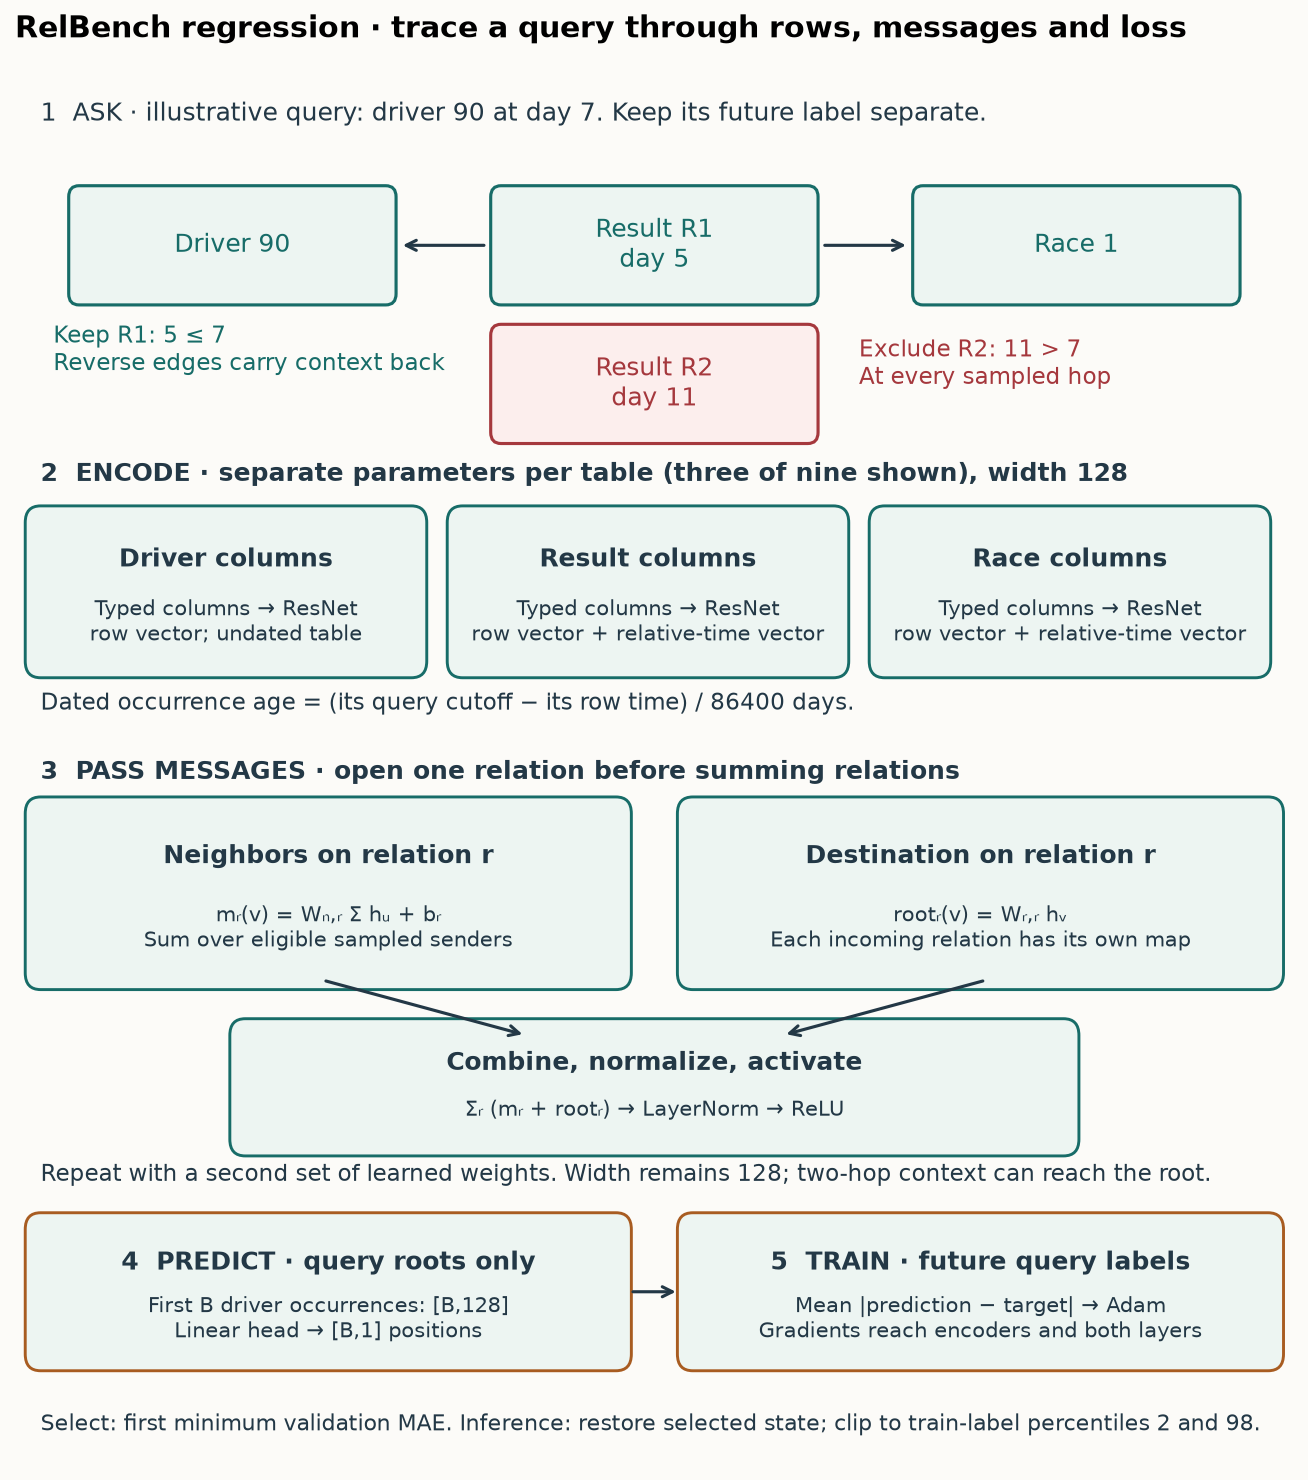<figcaption>The released regression path: query-specific sampling, per-table encoders and relative ages, two typed sum-aggregation layers, seed readout, loss and validation selection.</figcaption></figure>

**Diagram trace.** Trace legal Result R1 toward the driver. Find the separate neighbor and root transforms before the relation sum, then count the supervised outputs. On a narrow screen, scroll the figure sideways.

### 5.1 Encode columns into row vectors

For a node type `T`, collect its sampled rows into a TensorFrame: tensors grouped by semantic column type, with column identities retained. Numeric values receive numerical encodings; categories receive learned embeddings; timestamps receive time encodings. Text is first converted to frozen 300-dimensional GloVe-based sentence vectors in this release. Keys specify graph structure and are removed from predictive feature columns.

Each table has its own four-block PyTorch Frame ResNet row encoder, with internal width 128, producing `H_T` of shape `[n_T,128]`. Here `n_T` is the number of sampled copies of that table's rows, not necessarily the number of unique database entities. A residual block learns a correction to its input representation. The modality encoders and row network turn unlike columns into a common-sized vector; the graph network then combines vectors across tables. Revisit [Lesson 75](https://avistian.github.io/relational/lessons/0075-pytorch-frame-row-encoder.html) for the preprocessing boundary, after following this trace.

The benchmark materializes feature statistics on the database censored at the test cutoff. That reproduces the release; it is not train-only preprocessing. The declared run pins the text checkpoint and fixes the stochastic type-inference sample at seed 42, then resets each training seed. Historical inferred types and original random states were not published as a complete experiment identity.

### 5.2 Encode how old a neighboring row is

For a sampled copy of row `v` in query `q`, compute `age = (seed_time[q] − time[v]) / 86400`, measured in days. A sinusoidal positional encoding maps this scalar to 128 coordinates; a learned table-specific linear map transforms it. Add the result to the row embedding. `batch` identifies which query owns the sampled copy, so the same historical row can receive a different relative age for two queries.

This encoding communicates age; the sampler enforces eligibility. An age vector alone does not prevent future access. In the release, dated columns can also be encoded as absolute timestamp features. Absolute dates, relative ages, and temporal filtering have different roles. [Temporal encoder source](https://avistian.github.io/relational/labs/sources/l117/nn.py).

### 5.3 Aggregate typed messages

For one directed relation `r` and receiving row `v`, the selected sum-aggregation GraphSAGE operator computes

`m_r(v) = W_neighbor,r Σ[u in N_r(v)] h_u + b_r + W_root,r h_v`.

`N_r(v)` is the set of sampled senders connected through relation `r`. Each `W` is a learned matrix; `b` is a bias. Sum aggregation preserves multiplicity: three related events can produce a different vector from one otherwise identical event. It does not divide by neighbor count.

The heterogeneous layer sums relation outputs for each receiving node type. Notice that each relation has its own root transform; this is not necessarily equivalent to summing all neighbor messages and adding one shared root transform afterward. Then node-wise layer normalization rescales each row across its channels, and ReLU replaces negative coordinates with zero. Repeat the layer twice. Width stays 128.

**Numeric mechanism trace.** A receiver has scalar value 2, with neighbors 3 and 5. Set the neighbor weight to 2, root weight to 1, and bias to 0. The relation output is `2×(3+5)+1×2=18`. A mean-aggregation variant would give `2×4+2=10`. This is a scalar explanation of one operator, before normalization and nonlinearities; it is not a trained benchmark prediction.

Two layers give at most two edges of influence in the sampled graph. They do not expose every useful relational path. For example, `customer → purchase → product → purchase → customer` needs four edge traversals in this representation. Fey §4.3 makes this limitation an architectural research opportunity.

### 5.4 Read out the query and train

Disjoint temporal sampling keeps each query's computation separate. The first `B` driver embeddings correspond to the `B` seed queries. A linear head maps `[B,128]` to `[B,1]`, one predicted finishing-position value per query.

For targets `y_i` and predictions `ŷ_i`, mean absolute error is `MAE = Σ|ŷ_i−y_i| / B`. The training loss backpropagates through the head, graph layers, and trainable row encoders. Frozen GloVe vectors remain frozen. Adam uses learning rate 0.005. The selected schedule has 10 complete epochs and no subsampling of query rows.

At evaluation, the release clips predictions to the training target's 2nd and 98th percentiles. Select the first epoch with the lowest validation MAE, restoring the complete selected model state. Uniform neighbor sampling means reevaluating that checkpoint can produce a different validation number from the selection-time estimate. Preserve and report both instead of silently treating them as identical.



## 6 · What the full selected reproduction establishes

The empirical target is **Robinson et al., RelBench v1 Table 7, `rel-f1/driver-position`, RDL column**. It complements Fey's blueprint. It is not one of the older beta tables in Fey's Appendix D, which use different tasks and database versions. [RelBench Tables 7 and 9](https://arxiv.org/html/2407.20060v1#A2).

**Predict before reading the measured result:** if a released pipeline completes and reproduces the model outputs, what additional evidence would you need before claiming historical paper identity?

**Five complete full-data runs. Author-reference evidence, separate from student execution.**

| Split | Mean MAE | Sample seed SD | Paper mean | Descriptive verdict |
|---|---:|---:|---:|---|
| val | 3.18180 | 0.04348 | 3.193 | CLOSE |
| test | 4.13392 | 0.15660 | 4.022 | CLOSE |

All **6,295 final query predictions** were independently rescored and compared with the original released model on the same sampled inputs. Maximum raw-output discrepancy: **2.86e-06**, within the predeclared numerical tolerance. The complete graph has **74,063 rows** at the release test cutoff.

Recorded pilot plus five-fit worker resource estimate: **USD0.0577**. Build/startup/storage overhead is not itemized; the plan reserves USD3.499264 for overhead beneath the USD10 aggregate cap. See [all seeds and protocol status](https://avistian.github.io/relational/labs/evidence/l117/summary.json).

**The selected released-protocol experiment is COMPLETE. Historical identity and whole-paper parity remain NOT_ESTABLISHED.** Score verdicts compare means only; they are not statistical equivalence tests. Live Colab remains NOT_CHECKED.

| Contract | Selected experiment |
|---|---|
| Data | All nine released F1 tables, censored at the release test cutoff; hash-checked archives |
| Queries | 7,453 train; 499 validation; 760 test; original ordering and temporal splits |
| Fits | Five fresh seeds 0–4, each 10 complete epochs |
| Model | Four-block row ResNets; width 128; two heterogeneous GraphSAGE layers; sum aggregation; scalar head |
| Sampling | Uniform, disjoint temporal neighborhoods; batch size 512; source fanouts `[128,64]` |
| Optimization | Adam .005; mean L1; first minimum validation checkpoint |
| Reporting | MAE on every query; inference clamped to train percentiles; sample seed SD |
| Comparison | Published means 3.193 / 4.022; predeclared descriptive CLOSE tolerance 0.2 MAE |

The paper's hyperparameter table says 128 neighbors; the selected release halves that at the second hop. The package preserves `[128,64]` and records the distinction. The five historical seeds are not specified as a recoverable sequence; 0–4 is our declared sequence. Current libraries and type-inference state are also recorded deviations. A close score does not erase them.

**Interpret the scope.** Independent scoring checks metric arithmetic and population identity. Original-model replay on the same sampled inputs checks the neural computation. Timestamp checks test the declared sample boundary. None proves that the public archive reconstructs real ingestion history, that the whole paper has been reproduced, or that this model beats engineered features on your database. We do not rerun a tuning search against the test result to make the number look closer.



## 7 · Read the whole Fey paper with a claim ledger

Read the [final ICML paper](https://proceedings.mlr.press/v235/fey24a.html), not just the abstract. Use this sequence to connect its pieces:

| Reading | Write this artifact before moving on |
|---|---|
| §§1–2, Figures 1–3 | Define one entity, prediction time, target window, and legal input set |
| §§3.1–3.3, Figure 4 | Draw schema, entity, and query computation graphs for the same example |
| §3.4 and Appendix A–B | Trace one typed message and identify the timestamp checked at every hop |
| §4 and Figure 5 | Name one unresolved limitation of sampling, graph design, architecture, or training |
| §5 | Explain the connection to statistical relational learning, tabular ML, and earlier relational GNNs |
| §6 and Appendices C–D | Separate the beta benchmark's tasks and evidence from the later RelBench reproduction here |

Section 4 is a research agenda: scaling across databases, alternative graph constructions, SQL-inspired operators, multitask learning, and multimodal/foundation models. These possibilities are not all implemented or experimentally established by the position paper. Section 5 also makes clear that relational learning has a history; the planned Lesson 118 returns to Cvitkovic's earlier approach.

For a skeptical reading, ask: what information can an engineered baseline access? What is actually learned? What preprocessing uses future distributions? How many hops reach the relevant signal? What observation would contradict the claimed advantage? This is how the bridge serves the course mission without converting the position paper's motivation into a universal performance claim.



## 8 · Lab, exit defense, and spaced return

The default notebook downloads the small hash-checked real F1 database and applies your three functions to a real neighborhood. It also uses tiny counterexamples to expose indexing and time errors. The full model and training loop are visible afterward; the expensive reproduction gate defaults off. Three CHECK cells provide immediate feedback. Do not copy the solution before making a prediction and attempting each function.

Submit your functions, generated `l117-task-report.json`, and this defense:

1. Explain why a result row is a node and why both directed relationships are useful.
2. Trace one prediction from query row through legal input rows, encoders, messages, head, and target.
3. Explain why `input_id`, `n_id`, and `batch` mean different things.
4. Name two temporal claims the release checks and two historical claims it cannot establish.
5. State the reproduction result and its limits without turning a selected task into a whole-paper claim.

Explain why two predictions for the same driver at different dates require distinct query labels and potentially distinct computation graphs. Include the role of input_id, n_id and batch.

Tomorrow, redraw the three graphs without notes. In a week, explain why two queries about the same driver need separate computation graphs. Interleave that exercise with the missing-update diagnosis from Lesson 116.

**Learner status: PENDING_WRITTEN_DEFENSE.** Ask the teacher follow-up questions about any step, or paste your graph and EXIT ticket for feedback. Author execution verifies the package; your explanation supplies the learning evidence.

<!-- sequence-next:start -->
**Carry this forward.** Compare this modern stack with the earlier target-specific extraction and readout in Cvitkovic. [Continue to Lesson 118](https://avistian.github.io/relational/lessons/0118-cvitkovic-relational-gnn.html).
<!-- sequence-next:end -->


## Visible implementation and live tasks

The full relational model, graph constructor, sampler configuration, loss, checkpoint selection and trainer are below. RelBench-derived classes are MIT licensed. Frame and PyG operators remain named library dependencies; their pinned source is distributed alongside the lesson. Each task CHECK uses your live function, and the real-data RUN cell depends on all three.

### Key identities (PROVIDED) · PROVIDED

In [ ]:
import numpy as np

### Task 1: map foreign keys to row positions

**Goal:** Map arbitrary keys to row positions; preserve repeated references and reject invalid identities.

**Why:** the graph computation must preserve key, time and query identity.

In [ ]:
def foreign_key_edges(primary_keys, foreign_keys):
    raise NotImplementedError("TODO: foreign_key_edges")

In [ ]:
def check_edges(fn):
    got=fn([90,10,40],[40,None,90,40])
    np.testing.assert_array_equal(got,np.array([[0,2,3],[2,0,2]]))
    try:fn([90,90],[90])
    except ValueError:pass
    else:raise AssertionError('Duplicate primary key accepted')
    try:fn([90],[12])
    except ValueError:pass
    else:raise AssertionError('Unknown non-null foreign key accepted')
    assert fn([90],[None]).shape==(2,0)
check_edges(foreign_key_edges)
print("PASS: foreign_key_edges")

### Task 2: preserve one query cutoff across every hop

**Goal:** Expand permitted neighbors while holding the original prediction time fixed.

**Why:** the graph computation must preserve key, time and query identity.

In [ ]:
def temporal_nodes(edges, times, seed, cutoff, hops):
    raise NotImplementedError("TODO: temporal_nodes")

In [ ]:
def check_cutoff(fn):
    # The middle timeless dimension must not reset the seed cutoff.
    edges=[(0,1),(1,0),(1,2),(2,1),(1,3),(3,1)]
    times=[None,None,5,11]
    assert set(fn(edges,times,0,7,2))=={0,1,2}
    assert set(fn(edges,times,0,11,2))=={0,1,2,3}
    assert set(fn(edges,times,0,4,2))=={0,1}
    assert set(fn(edges,times,0,7,0))=={0}
check_cutoff(temporal_nodes)
print("PASS: temporal_nodes")

### Task 3: attach labels by query identity, not entity identity

**Goal:** Attach future targets in sampled query order, preserving repeated entities.

**Why:** the graph computation must preserve key, time and query identity.

In [ ]:
def query_targets(targets, input_id):
    raise NotImplementedError("TODO: query_targets")

In [ ]:
def check_targets(fn):
    # Query rows 0 and 2 refer to the same entity at different times.
    target=np.array([3.,7.,11.]); input_id=np.array([2,0,1])
    np.testing.assert_array_equal(fn(target,input_id),[11.,3.,7.])
    np.testing.assert_array_equal(fn(target,np.array([],dtype=int)),[])
check_targets(query_targets)
print("PASS: query_targets")

### Full released model dependencies (PROVIDED) · PROVIDED

In [ ]:
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

### Relational node predictor (PROVIDED) · PROVIDED

In [ ]:
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

### Full database to REG and query transform (PROVIDED) · PROVIDED

In [ ]:
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )

### Full released-protocol training loop (PROVIDED) · PROVIDED

In [ ]:
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=3.193, test=4.022)


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first lowest validation MAE, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
    best=float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.clamp(*bounds).view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==7453
        val,_,_=predict(loaders['val'])
        score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
        trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
        if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=float(np.mean(np.abs(pred-target)))
        official=task.evaluate(pred,tables[split])['mae']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
        scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

## RUN · your functions on real F1 rows

This is a three-table teaching view of drivers, results and constructors from the complete released archive, including rows after the query date so your cutoff has work to do. The author benchmark uses all nine tables with the release censoring policy. Neither this graph walk nor its success is a predictive benchmark.

In [ ]:
import io,json,zipfile,hashlib,urllib.request
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq

def archive(url,expected):
    payload=urllib.request.urlopen(url,timeout=60).read()
    assert hashlib.sha256(payload).hexdigest()==expected,'Archive identity changed'
    return zipfile.ZipFile(io.BytesIO(payload))

with archive('https://relbench.stanford.edu/download/rel-f1/db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482') as z:
    tables={name:pq.read_table(io.BytesIO(z.read('db/'+name+'.parquet')),use_threads=False).to_pandas() for name in ['drivers','results','constructors']}
with archive('https://relbench.stanford.edu/download/rel-f1/tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e') as z:
    train=pq.read_table(io.BytesIO(z.read('driver-position/train.parquet')),use_threads=False).to_pandas()

# Real released key identities; each student function affects the final report.
drivers,results,constructors=(tables[k] for k in ['drivers','results','constructors'])
nd,nr=len(drivers),len(results)
rd=foreign_key_edges(drivers.driverId.tolist(),results.driverId.tolist())
rc=foreign_key_edges(constructors.constructorId.tolist(),results.constructorId.tolist())
edges=[]
for src,dst in rd.T:edges.extend([(int(dst),nd+int(src)),(nd+int(src),int(dst))])
for src,dst in rc.T:edges.extend([(nd+int(src),nd+nr+int(dst)),(nd+nr+int(dst),nd+int(src))])
times=[None]*nd+[int(x.value//10**9) for x in results.date]+[None]*len(constructors)
query=train.iloc[0];cutoff=int(query.date.value//10**9);seed=drivers.driverId.tolist().index(int(query.driverId))
selected=temporal_nodes(edges,times,seed,cutoff,2)
assert seed in selected
future=[i for i in selected if times[i] is not None and times[i]>cutoff]
assert not future
historic=[i-nd for i in selected if nd<=i<nd+nr]
assert len(historic)>0
input_ids=np.array([2,0,1]);attached=query_targets(train.position.to_numpy(),input_ids)
np.testing.assert_array_equal(attached,train.iloc[input_ids].position.to_numpy())
report={'status':'PASS','dataset':'rel-f1 released real rows; three-table learning view',
        'query_driver_key':int(query.driverId),'query_time':str(query.date),
        'nodes_in_learning_view':len(times),'directed_edges_in_learning_view':len(edges),
        'eligible_two_hop_nodes':len(selected),'historic_result_rows':len(historic),
        'future_rows_included':len(future),'query_row_order':input_ids.tolist(),
        'attached_targets':attached.tolist(),'full_benchmark':'Separate author evidence; not run by this cell',
        'learner_status':'PENDING_WRITTEN_DEFENSE'}
Path('l117-task-report.json').write_text(json.dumps(report,indent=2));print(json.dumps(report,indent=2))


## Read the pinned library operator · resnet.py

The model calls this library implementation. It is reproduced here for inspection; execute the installed pinned package, not an improvised partial port.

```python
from __future__ import annotations

import math
from typing import Any

from torch import Tensor
from torch.nn import (
    BatchNorm1d,
    Dropout,
    LayerNorm,
    Linear,
    Module,
    ReLU,
    Sequential,
)

import torch_frame
from torch_frame import TensorFrame, stype
from torch_frame.data.stats import StatType
from torch_frame.nn.encoder.stype_encoder import (
    EmbeddingEncoder,
    LinearEncoder,
    StypeEncoder,
)
from torch_frame.nn.encoder.stypewise_encoder import StypeWiseFeatureEncoder


class FCResidualBlock(Module):
    r"""Fully connected residual block.

    Args:
        in_channels (int): The number of input channels.
        out_channels (int): The number of output channels.
        normalization (str, optional): The type of normalization to use.
            :obj:`layer_norm`, :obj:`batch_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.0`, i.e.,
            no dropout).
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.0,
    ) -> None:
        super().__init__()
        self.lin1 = Linear(in_channels, out_channels)
        self.lin2 = Linear(out_channels, out_channels)
        self.relu = ReLU()
        self.dropout = Dropout(dropout_prob)

        self.norm1: BatchNorm1d | LayerNorm | None
        self.norm2: BatchNorm1d | LayerNorm | None
        if normalization == "batch_norm":
            self.norm1 = BatchNorm1d(out_channels)
            self.norm2 = BatchNorm1d(out_channels)
        elif normalization == "layer_norm":
            self.norm1 = LayerNorm(out_channels)
            self.norm2 = LayerNorm(out_channels)
        else:
            self.norm1 = self.norm2 = None

        self.shortcut: Linear | None
        if in_channels != out_channels:
            self.shortcut = Linear(in_channels, out_channels)
        else:
            self.shortcut = None

    def reset_parameters(self) -> None:
        self.lin1.reset_parameters()
        self.lin2.reset_parameters()
        if self.norm1 is not None:
            self.norm1.reset_parameters()
        if self.norm2 is not None:
            self.norm2.reset_parameters()
        if self.shortcut is not None:
            self.shortcut.reset_parameters()

    def forward(self, x: Tensor) -> Tensor:
        out = self.lin1(x)
        out = self.norm1(out) if self.norm1 else out
        out = self.relu(out)
        out = self.dropout(out)

        out = self.lin2(out)
        out = self.norm2(out) if self.norm2 else out
        out = self.relu(out)
        out = self.dropout(out)

        if self.shortcut is not None:
            x = self.shortcut(x)

        out = out + x

        return out


class ResNet(Module):
    r"""The ResNet model introduced in the
    `"Revisiting Deep Learning Models for Tabular Data"
    <https://arxiv.org/abs/2106.11959>`_ paper.

    .. note::

        For an example of using ResNet, see `examples/revisiting.py
        <https://github.com/pyg-team/pytorch-frame/blob/master/examples/
        revisiting.py>`_.

    Args:
        channels (int): The number of channels in the backbone layers.
        out_channels (int): The number of output channels in the decoder.
        num_layers (int): The number of layers in the backbone.
        col_stats(dict[str,Dict[:class:`torch_frame.data.stats.StatType`,Any]]):
             A dictionary that maps column name into stats.
             Available as :obj:`dataset.col_stats`.
        col_names_dict (dict[:class:`torch_frame.stype`, List[str]]): A
            dictionary that maps stype to a list of column names. The column
            names are sorted based on the ordering that appear in
            :obj:`tensor_frame.feat_dict`. Available as
            :obj:`tensor_frame.col_names_dict`.
        stype_encoder_dict
            (dict[:class:`torch_frame.stype`,
            :class:`torch_frame.nn.encoder.StypeEncoder`], optional):
            A dictionary mapping stypes into their stype encoders.
            (default: :obj:`None`, will call :obj:`EmbeddingEncoder()`
            for categorical feature and :obj:`LinearEncoder()` for
            numerical feature)
        normalization (str, optional): The type of normalization to use.
            :obj:`batch_norm`, :obj:`layer_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.2`).
    """
    def __init__(
        self,
        channels: int,
        out_channels: int,
        num_layers: int,
        col_stats: dict[str, dict[StatType, Any]],
        col_names_dict: dict[torch_frame.stype, list[str]],
        stype_encoder_dict: dict[torch_frame.stype, StypeEncoder]
        | None = None,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.2,
    ) -> None:
        super().__init__()

        if stype_encoder_dict is None:
            stype_encoder_dict = {
                stype.categorical: EmbeddingEncoder(),
                stype.numerical: LinearEncoder(),
            }

        self.encoder = StypeWiseFeatureEncoder(
            out_channels=channels,
            col_stats=col_stats,
            col_names_dict=col_names_dict,
            stype_encoder_dict=stype_encoder_dict,
        )

        num_cols = sum(
            [len(col_names) for col_names in col_names_dict.values()])
        in_channels = channels * num_cols
        self.backbone = Sequential(*[
            FCResidualBlock(
                in_channels if i == 0 else channels,
                channels,
                normalization=normalization,
                dropout_prob=dropout_prob,
            ) for i in range(num_layers)
        ])

        self.decoder = Sequential(
            LayerNorm(channels),
            ReLU(),
            Linear(channels, out_channels),
        )

        self.reset_parameters()

    def reset_parameters(self) -> None:
        self.encoder.reset_parameters()
        for block in self.backbone:
            block.reset_parameters()
        self.decoder[0].reset_parameters()
        self.decoder[-1].reset_parameters()

    def forward(self, tf: TensorFrame) -> Tensor:
        r"""Transforming :class:`TensorFrame` object into output prediction.

        Args:
            tf (TensorFrame): Input :class:`TensorFrame` object.

        Returns:
            torch.Tensor: Output of shape [batch_size, out_channels].
        """
        x, _ = self.encoder(tf)

        # Flattening the encoder output
        x = x.view(x.size(0), math.prod(x.shape[1:]))

        x = self.backbone(x)
        out = self.decoder(x)
        return out

```

## Read the pinned library operator · sage_conv.py

The model calls this library implementation. It is reproduced here for inspection; execute the installed pinned package, not an improvised partial port.

```python
from typing import List, Optional, Tuple, Union

import torch.nn.functional as F
from torch import Tensor

from torch_geometric.nn.aggr import Aggregation, MultiAggregation
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.typing import Adj, OptPairTensor, Size, SparseTensor
from torch_geometric.utils import spmm


class SAGEConv(MessagePassing):
    r"""The GraphSAGE operator from the `"Inductive Representation Learning on
    Large Graphs" <https://arxiv.org/abs/1706.02216>`_ paper.

    .. math::
        \mathbf{x}^{\prime}_i = \mathbf{W}_1 \mathbf{x}_i + \mathbf{W}_2 \cdot
        \mathrm{mean}_{j \in \mathcal{N(i)}} \mathbf{x}_j

    If :obj:`project = True`, then :math:`\mathbf{x}_j` will first get
    projected via

    .. math::
        \mathbf{x}_j \leftarrow \sigma ( \mathbf{W}_3 \mathbf{x}_j +
        \mathbf{b})

    as described in Eq. (3) of the paper.

    Args:
        in_channels (int or tuple): Size of each input sample, or :obj:`-1` to
            derive the size from the first input(s) to the forward method.
            A tuple corresponds to the sizes of source and target
            dimensionalities.
        out_channels (int): Size of each output sample.
        aggr (str or Aggregation, optional): The aggregation scheme to use.
            Any aggregation of :obj:`torch_geometric.nn.aggr` can be used,
            *e.g.*, :obj:`"mean"`, :obj:`"max"`, or :obj:`"lstm"`.
            (default: :obj:`"mean"`)
        normalize (bool, optional): If set to :obj:`True`, output features
            will be :math:`\ell_2`-normalized, *i.e.*,
            :math:`\frac{\mathbf{x}^{\prime}_i}
            {\| \mathbf{x}^{\prime}_i \|_2}`.
            (default: :obj:`False`)
        root_weight (bool, optional): If set to :obj:`False`, the layer will
            not add transformed root node features to the output.
            (default: :obj:`True`)
        project (bool, optional): If set to :obj:`True`, the layer will apply a
            linear transformation followed by an activation function before
            aggregation (as described in Eq. (3) of the paper).
            (default: :obj:`False`)
        bias (bool, optional): If set to :obj:`False`, the layer will not learn
            an additive bias. (default: :obj:`True`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.

    Shapes:
        - **inputs:**
          node features :math:`(|\mathcal{V}|, F_{in})` or
          :math:`((|\mathcal{V_s}|, F_{s}), (|\mathcal{V_t}|, F_{t}))`
          if bipartite,
          edge indices :math:`(2, |\mathcal{E}|)`
        - **outputs:** node features :math:`(|\mathcal{V}|, F_{out})` or
          :math:`(|\mathcal{V_t}|, F_{out})` if bipartite
    """
    def __init__(
        self,
        in_channels: Union[int, Tuple[int, int]],
        out_channels: int,
        aggr: Optional[Union[str, List[str], Aggregation]] = "mean",
        normalize: bool = False,
        root_weight: bool = True,
        project: bool = False,
        bias: bool = True,
        **kwargs,
    ):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.normalize = normalize
        self.root_weight = root_weight
        self.project = project

        if isinstance(in_channels, int):
            in_channels = (in_channels, in_channels)

        if aggr == 'lstm':
            kwargs.setdefault('aggr_kwargs', {})
            kwargs['aggr_kwargs'].setdefault('in_channels', in_channels[0])
            kwargs['aggr_kwargs'].setdefault('out_channels', in_channels[0])

        super().__init__(aggr, **kwargs)

        if self.project:
            if in_channels[0] <= 0:
                raise ValueError(f"'{self.__class__.__name__}' does not "
                                 f"support lazy initialization with "
                                 f"`project=True`")
            self.lin = Linear(in_channels[0], in_channels[0], bias=True)

        if isinstance(self.aggr_module, MultiAggregation):
            aggr_out_channels = self.aggr_module.get_out_channels(
                in_channels[0])
        else:
            aggr_out_channels = in_channels[0]

        self.lin_l = Linear(aggr_out_channels, out_channels, bias=bias)
        if self.root_weight:
            self.lin_r = Linear(in_channels[1], out_channels, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        if self.project:
            self.lin.reset_parameters()
        self.lin_l.reset_parameters()
        if self.root_weight:
            self.lin_r.reset_parameters()

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        if self.project and hasattr(self, 'lin'):
            x = (self.lin(x[0]).relu(), x[1])

        # propagate_type: (x: OptPairTensor)
        out = self.propagate(edge_index, x=x, size=size)
        out = self.lin_l(out)

        x_r = x[1]
        if self.root_weight and x_r is not None:
            out = out + self.lin_r(x_r)

        if self.normalize:
            out = F.normalize(out, p=2., dim=-1)

        return out

    def message(self, x_j: Tensor) -> Tensor:
        return x_j

    def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
        if isinstance(adj_t, SparseTensor):
            adj_t = adj_t.set_value(None, layout=None)
        return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}({self.in_channels}, '
                f'{self.out_channels}, aggr={self.aggr})')

```

## Full named reproduction · default OFF

Five complete 10-epoch runs. This may require GPU setup and incurs compute costs on paid hosts. The notebook gate has no spending cap; the supplied author Modal runner limits reservations under the USD10 aggregate plan. A run in a different environment is new evidence, not automatically paper-identical.

In [ ]:
TEXT_SPEC = {'model': 'sentence-transformers/average_word_embeddings_glove.6B.300d', 'revision': 'e5e8fec6971be8960cfaa853a77a6ddc62a265d7'}
ORIGINAL_MODEL_SOURCE = 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n'
# Optional five-seed full-data experiment. Native pyg-lib and a compatible GPU runtime required.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    from relbench.datasets import get_dataset
    from relbench.tasks import get_task
    from relbench.modeling.utils import get_stype_proposal
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1)
    seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task=get_task('rel-f1','driver-position',download=True)
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
        assert hashlib.sha256((Path(dataset.cache_dir)/name).read_bytes()).hexdigest()==expected
    types=get_stype_proposal(db)
    text_model=SentenceTransformer(TEXT_SPEC['model'],revision=TEXT_SPEC['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    reference_namespace={}
    exec(ORIGINAL_MODEL_SOURCE,reference_namespace)
    records=[fit_rdl(data,stats,task,seed,Path('l117-full')/f'seed-{seed}',10,'cuda' if torch.cuda.is_available() else 'cpu',reference_namespace['Model']) for seed in range(5)]
    print({s:float(np.mean([r['scores'][s] for r in records])) for s in ['val','test']})
else:
    print('Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.')


## EXIT TICKET

Submit your three functions, `l117-task-report.json`, and the five-part defense from Section 8. Explain one rejected counterexample for each function. **PENDING_WRITTEN_DEFENSE**.